# What the dataset contains

Extracted from [Kaggle](https://www.kaggle.com/datasets/adilimadeddinehosni/multi-resistance-antibiotic-susceptibility)

This dataset provides a comprehensive collection of bacterial isolates tested against a wide panel of antibiotics. Each row represents a unique bacterial strain isolated from a patient sample, along with associated demographic information, clinical risk factors, and antibiotic susceptibility test results.

The dataset has been structured to allow researchers to study:

    Patterns of multi-drug resistance (MDR) across bacterial species
    The relationship between patient risk factors (e.g., diabetes, hypertension, hospitalization history) and resistance
    Epidemiological trends of resistance across antibiotic families
    The impact of data quality challenges such as missing values, inconsistent labels, and free-text entries

This dataset is well-suited for antibiotic resistance surveillance, exploratory data analysis (EDA), predictive modeling, and teaching in data-driven microbiology.
🔬Antibiotic Families and Molecules

The dataset includes 15+ antibiotics spanning 4 major families, representing commonly prescribed agents in clinical practice. Results are coded primarily as:

    R → Resistant
    S → Susceptible with occasional alternative encodings such as i, Intermediate, r, s, NA, missing.

β-lactams (Beta-lactams)

Target bacterial cell wall synthesis by inhibiting penicillin-binding proteins (PBPs).

    AMX/AMP → Amoxicillin / Ampicillin (aminopenicillins)
    AMC → Amoxicillin + Clavulanic Acid (β-lactam/β-lactamase inhibitor)
    CZ → Cefazolin (first-generation cephalosporin)
    FOX → Cefoxitin (second-generation cephamycin)
    CTX/CRO → Cefotaxime / Ceftriaxone (third-generation cephalosporins)
    IPM → Imipenem (a carbapenem, considered a last-resort treatment)

Aminoglycosides (Aminosides)

Bind to the 30S ribosomal subunit, inhibiting protein synthesis.

    GEN → Gentamicin
    AN → Amikacin (broader spectrum, often effective against gentamicin-resistant strains)

Quinolones / Fluoroquinolones

Inhibit bacterial DNA gyrase and topoisomerase IV, interfering with DNA replication.

    Acide nalidixique → Nalidixic Acid (first-generation quinolone, Gram-negative coverage)
    OFX → Ofloxacin (fluoroquinolone, broad spectrum)
    CIP → Ciprofloxacin (fluoroquinolone, widely used for urinary tract infections)

Other Important Agents

Include drugs from various classes used for Gram-positive, Gram-negative, or multidrug-resistant infections.

    C → Chloramphenicol (broad-spectrum, rarely used due to toxicity but still tested)
    Co-trimoxazole → Combination of Trimethoprim + Sulfamethoxazole (folate pathway inhibitor)
    Furanes → Nitrofurantoin (commonly used for urinary tract infections)
    Colistine → Colistin (polymyxin class, last-line therapy for carbapenem-resistant organisms)

🧾Dataset Structure
Identification & Demographics

    ID → Unique strain identifier (e.g., S290)
    Souche → Bacterial species name (e.g., Escherichia coli, Klebsiella pneumoniae, Pseudomonas aeruginosa)
    Age → Patient age (numeric)
    Gender → Encoded as M / F

Risk Factors

    Diabetes → {Yes, No, Y, N, True, 1, ?}
    Hypertension → {Yes, No, missing, ?}
    Hospital_before → {Yes, No} (prior hospitalization within the last 6 months)
    Infection_Freq → Frequency of recurrent infections
        Never → no recurrence
        Rarely → <2 times per year
        Regularly → <6 times per year
        Often → ≥6 times per year

Antibiotic Susceptibility Test (AST) Results

Each column corresponds to one antibiotic (e.g., GEN, CIP, IPM)

Results: {R, S, i, Intermediate, NA, missing}
Metadata

Collection_Date → Date of sample collection (multiple formats: ISO, DD/MM/YYYY, textual month formats) Notes → Free-text comments (multilingual, includes English, French, Spanish, Arabic)
📊 Dataset Dimensions

Rows: ~10,000 isolates

Columns: ~25 features (including demographics, risk factors, and AST results)

Coverage: Multiple bacterial species, diverse antibiotics, heterogeneous patients
🧪 Analytical Opportunities

Researchers and data scientists can explore:

    Prevalence of resistance within and across antibiotic families
    Multi-drug resistance profiles (isolates resistant to ≥3 families)
    Association between risk factors and resistance (e.g., diabetes vs. resistance to aminoglycosides)
    Epidemiological trends (distribution by age, gender, hospitalization history)
    Resistance clustering across species and families
    Data quality issues (handling noisy categorical labels, missing values, and unstructured notes)

🎯 Intended Use Cases

    Antimicrobial Resistance Surveillance → Identify species-antibiotic patterns and MDR strains
    Predictive Modeling → Build classifiers for resistance prediction (binary/multilabel classification)
    Data Cleaning Challenges → Handle categorical inconsistencies, missing data, and corrupted values
    Teaching & Training → Use as a case study in microbiology, data science, and machine learning courses
    Benchmarking → Compare ML algorithms for classification, clustering, or dimensionality reduction

✨ Key Highlights

    ✅ Coverage of 15+ antibiotics across 4 major families
    ✅ Inclusion of clinical risk factors to study associations with resistance
    ✅ Demographic metadata (age, gender, hospitalization)
    ✅ Messy data elements (typos, missing values, inconsistent encodings, multilingual notes)
    ✅ Suitable for advanced exploratory, statistical, and machine learning analysis

💡 This dataset enables detailed study of antimicrobial resistance patterns, supports multi-drug resistance modeling, and provides a realistic foundation for clinical data analysis and decision support research.

---
# **Importing Libraries and data**
---

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# setting the theme
sns.set_theme()

In [3]:
antibiotics_path = "../../datasets/03_antibiotics/Bacteria_dataset_Multiresistance.csv"

In [4]:
df = pd.read_csv(antibiotics_path)

---
# **Basic questions to the data in hand**
---

In [5]:
# How big is the data
df.shape

(10710, 27)

In [6]:
# How does the data look like
df.head()

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA


In [7]:
# What are the columns
np.array(df.columns)

array(['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches',
       'Diabetes', 'Hypertension', 'Hospital_before', 'Infection_Freq',
       'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN',
       'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole',
       'Furanes', 'colistine', 'Collection_Date', 'Notes'], dtype=object)

In [8]:
# Data type of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10710 entries, 0 to 10709
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 10710 non-null  object
 1   Name               10710 non-null  object
 2   Email              10710 non-null  object
 3   Address            10710 non-null  object
 4   age/gender         10089 non-null  object
 5   Souches            10070 non-null  object
 6   Diabetes           10075 non-null  object
 7   Hypertension       10080 non-null  object
 8   Hospital_before    10073 non-null  object
 9   Infection_Freq     10071 non-null  object
 10  AMX/AMP            10052 non-null  object
 11  AMC                10078 non-null  object
 12  CZ                 10082 non-null  object
 13  FOX                10085 non-null  object
 14  CTX/CRO            10086 non-null  object
 15  IPM                10077 non-null  object
 16  GEN                10067 non-null  objec

In [9]:
# Null values
df.isnull().sum()

ID                     0
Name                   0
Email                  0
Address                0
age/gender           621
Souches              640
Diabetes             635
Hypertension         630
Hospital_before      637
Infection_Freq       639
AMX/AMP              658
AMC                  632
CZ                   628
FOX                  625
CTX/CRO              624
IPM                  633
GEN                  643
AN                   628
Acide nalidixique    622
ofx                  618
CIP                  633
C                    629
Co-trimoxazole       640
Furanes              637
colistine            636
Collection_Date      669
Notes                112
dtype: int64

In [10]:
# Percentage of missing values
print(f'Percentage of missing values: {df.isnull().sum() / len(df) * 100}')

Percentage of missing values: ID                   0.000000
Name                 0.000000
Email                0.000000
Address              0.000000
age/gender           5.798319
Souches              5.975724
Diabetes             5.929038
Hypertension         5.882353
Hospital_before      5.947712
Infection_Freq       5.966387
AMX/AMP              6.143791
AMC                  5.901027
CZ                   5.863679
FOX                  5.835668
CTX/CRO              5.826331
IPM                  5.910364
GEN                  6.003735
AN                   5.863679
Acide nalidixique    5.807656
ofx                  5.770308
CIP                  5.910364
C                    5.873016
Co-trimoxazole       5.975724
Furanes              5.947712
colistine            5.938375
Collection_Date      6.246499
Notes                1.045752
dtype: float64


In [11]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

---
# **Data Cleaning**
---

In [12]:
del_cols = ['ID', 'Name', 'Email', 'Address', 'Collection_Date', 'Notes'] # not useful

In [13]:
df_nocols = df.drop(columns=del_cols)

In [14]:
df_nocols.shape

(10710, 21)

## Storing species data into a new species column

In [15]:
# Storing species data into seperate column
df_nocols['species'] = df['Souches'].str.split(n=1, expand=True)[1]

# n=1 -> split once
# expand=True -> return as dataframe instead of list

## Making sense of the age and gender column

In [16]:
# to replace the '/' from the age/gender column with ' ' (space) and then storing age and gender in the seperate column
df_nocols['age'] = df['age/gender'].str.replace('/', ' ').str.split(n=1, expand=True)[0]
df_nocols['gender'] = df['age/gender'].str.replace('/', ' ').str.split(n=1, expand=True)[1]

In [17]:
# before replacement
df_nocols['age'].unique()

array(['37', '29', '77', nan, '13', '57', '68', '18', '36', '49', '47',
       '74', '27', '34', '19', '38', '71', '54', '73', '66', '50', '52',
       '88', '80', '16', '86', '17', '76', '79', '20', '28', '51', '35',
       '2', '58', '22', '39', '87', '42', '61', '65', '31', '0', '69',
       '26', '23', '85', '24', '44', '40', '53', '4', '63', '48', '45',
       '6', '56', '1', '15', '60', '43', '64', '8', '70', '62', '10',
       '46', '82', '12', '41', '78', '33', '67', '30', '59', 'missing',
       '90', '84', '14', '32', '83', '81', '72', '9', '21', '75', '5',
       '55', '3', '25', '7', '11', '?', '89'], dtype=object)

In [18]:
# Replacing the 'missing' and '?' with np.nan for further processing
df_nocols['age'] = df_nocols['age'].replace('missing', np.nan)
df_nocols['age'] = df_nocols['age'].replace('?', np.nan)

In [19]:
# after replacement
df_nocols['age'].unique()

array(['37', '29', '77', nan, '13', '57', '68', '18', '36', '49', '47',
       '74', '27', '34', '19', '38', '71', '54', '73', '66', '50', '52',
       '88', '80', '16', '86', '17', '76', '79', '20', '28', '51', '35',
       '2', '58', '22', '39', '87', '42', '61', '65', '31', '0', '69',
       '26', '23', '85', '24', '44', '40', '53', '4', '63', '48', '45',
       '6', '56', '1', '15', '60', '43', '64', '8', '70', '62', '10',
       '46', '82', '12', '41', '78', '33', '67', '30', '59', '90', '84',
       '14', '32', '83', '81', '72', '9', '21', '75', '5', '55', '3',
       '25', '7', '11', '89'], dtype=object)

## Correcting the Species Column

In [20]:
# Replacing incorrect values
replacements = {
    'Enteobacteria spp.': 'Enterobacteria spp.',
    'Enter.bacteria spp.': 'Enterobacteria spp.',
    'E.cli': 'Escherichia coli',
    'E.coi':'Escherichia coli',
    'E. coli': 'Escherichia coli',
    'Klbsiella pneumoniae':'Klebsiella pneumoniae',
    'Klebsie.lla pneumoniae':'Klebsiella pneumoniae',
    'Prot.eus mirabilis':'Proteus mirabilis',
    'Proeus mirabilis':'Proteus mirabilis',
    'Protus mirabilis':'Proteus mirabilis',
    None: np.nan
}

In [21]:
df_nocols = df_nocols.replace({'species': replacements})

In [22]:
df_nocols['species'].unique()

array(['Escherichia coli', 'Morganella morganii', 'Proteus mirabilis',
       nan, 'Citrobacter spp.', 'Enterobacteria spp.',
       'Pseudomonas aeruginosa', 'Klebsiella pneumoniae',
       'Serratia marcescens', 'Acinetobacter baumannii'], dtype=object)

## Correcting the Hospital before column

In [23]:
hospital_replace = {
    '?': np.nan,
    'missing': np.nan
}

df_nocols['Hospital_before'].replace(hospital_replace).unique()

array(['No', nan, 'Yes'], dtype=object)

## Infection Frequency

In [24]:
fq_replace = {
    'unknown': np.nan,
    '?': np.nan,
    'error': np.nan,
    'missing': np.nan
}

df_nocols['Infection_Freq'] = df_nocols['Infection_Freq'].replace(fq_replace)
df_nocols['Infection_Freq'].unique()


array(['0.0', '3.0', nan, '1.0', '2.0'], dtype=object)

## Diabetes column

In [25]:
diabetes_replace = {
    'True': 'Yes',
    '?': np.nan,
    'missing': np.nan
}
df_nocols['Diabetes'].replace(diabetes_replace).unique()

array(['No', 'Yes', nan], dtype=object)

## Hypertension Column 

In [26]:
hyp_replace = {
        '?': np.nan,
    'missing': np.nan
}
df_nocols['Hypertension'].replace(hyp_replace).unique()

array(['No', nan, 'Yes'], dtype=object)

In [27]:
# Percentage of missing values in species column
for i in df_nocols.columns.to_list():
    print(f'Percentage of missing values in {i}: {(df_nocols[i].isnull().sum() / len(df_nocols[i]) * 100):.2f}%')

Percentage of missing values in age/gender: 5.80%
Percentage of missing values in Souches: 5.98%
Percentage of missing values in Diabetes: 5.93%
Percentage of missing values in Hypertension: 5.88%
Percentage of missing values in Hospital_before: 5.95%
Percentage of missing values in Infection_Freq: 9.30%
Percentage of missing values in AMX/AMP: 6.14%
Percentage of missing values in AMC: 5.90%
Percentage of missing values in CZ: 5.86%
Percentage of missing values in FOX: 5.84%
Percentage of missing values in CTX/CRO: 5.83%
Percentage of missing values in IPM: 5.91%
Percentage of missing values in GEN: 6.00%
Percentage of missing values in AN: 5.86%
Percentage of missing values in Acide nalidixique: 5.81%
Percentage of missing values in ofx: 5.77%
Percentage of missing values in CIP: 5.91%
Percentage of missing values in C: 5.87%
Percentage of missing values in Co-trimoxazole: 5.98%
Percentage of missing values in Furanes: 5.95%
Percentage of missing values in colistine: 5.94%
Percentage

## Cleaning each antibiotic column

In [28]:
antibiotic_replace = {
    's': 'S',
    'r': 'R',
    'Intermediate': 'I',
    'i': 'I',
    '?': np.nan,
    'missing': np.nan,
}

antibiotic_targetcols = ['AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine']

df_nocols[antibiotic_targetcols] = df_nocols[antibiotic_targetcols].replace(antibiotic_replace)

In [29]:
for i in antibiotic_targetcols:
    print(df_nocols[i].unique())

['R' 'S' nan 'I']
['R' nan 'S' 'I']
['R' 'S' nan 'I']
['R' nan 'S' 'I']
['R' 'S' nan 'I']
['R' 'S' nan 'I']
['S' nan 'R' 'I']
['S' nan 'R' 'I']
['S' nan 'R' 'I']
['S' nan 'R' 'I']
['S' 'R' nan 'I']
['R' 'S' nan 'I']
['S' nan 'R' 'I']
['S' nan 'R' 'I']
['S' nan 'R' 'I']


## Dropping nan values

In [ ]:
df_clean = df_nocols.copy()
df_clean = df_clean.dropna()

(9714, 24)

In [31]:
# Dropping unnecessary columns
df_clean = df_clean.drop(columns=['age/gender', 'Souches'])

In [32]:
to_number = ['age', 'Infection_Freq']
for col in to_number:
    df_clean[col] = pd.to_numeric(df_clean[col])

In [33]:
print(df_clean.dtypes)

Diabetes              object
Hypertension          object
Hospital_before       object
Infection_Freq       float64
AMX/AMP               object
AMC                   object
CZ                    object
FOX                   object
CTX/CRO               object
IPM                   object
GEN                   object
AN                    object
Acide nalidixique     object
ofx                   object
CIP                   object
C                     object
Co-trimoxazole        object
Furanes               object
colistine             object
species               object
age                    int64
gender                object
dtype: object


In [34]:
for i in df_clean.columns.to_list():
    print(f'Missing values in {i}: {(df_clean[i].isnull().sum()) / (len(df_clean[i])) * 100:.2f}%')

Missing values in Diabetes: 0.00%
Missing values in Hypertension: 0.00%
Missing values in Hospital_before: 0.00%
Missing values in Infection_Freq: 0.00%
Missing values in AMX/AMP: 0.00%
Missing values in AMC: 0.00%
Missing values in CZ: 0.00%
Missing values in FOX: 0.00%
Missing values in CTX/CRO: 0.00%
Missing values in IPM: 0.00%
Missing values in GEN: 0.00%
Missing values in AN: 0.00%
Missing values in Acide nalidixique: 0.00%
Missing values in ofx: 0.00%
Missing values in CIP: 0.00%
Missing values in C: 0.00%
Missing values in Co-trimoxazole: 0.00%
Missing values in Furanes: 0.00%
Missing values in colistine: 0.00%
Missing values in species: 0.00%
Missing values in age: 0.00%
Missing values in gender: 0.00%


---
# **Visualisations**
---

In [35]:
# setting palettes
sns.set_context('talk') # paper, notebook, talk or poster
sns.set_palette('bright')

## Age Distribution for infections

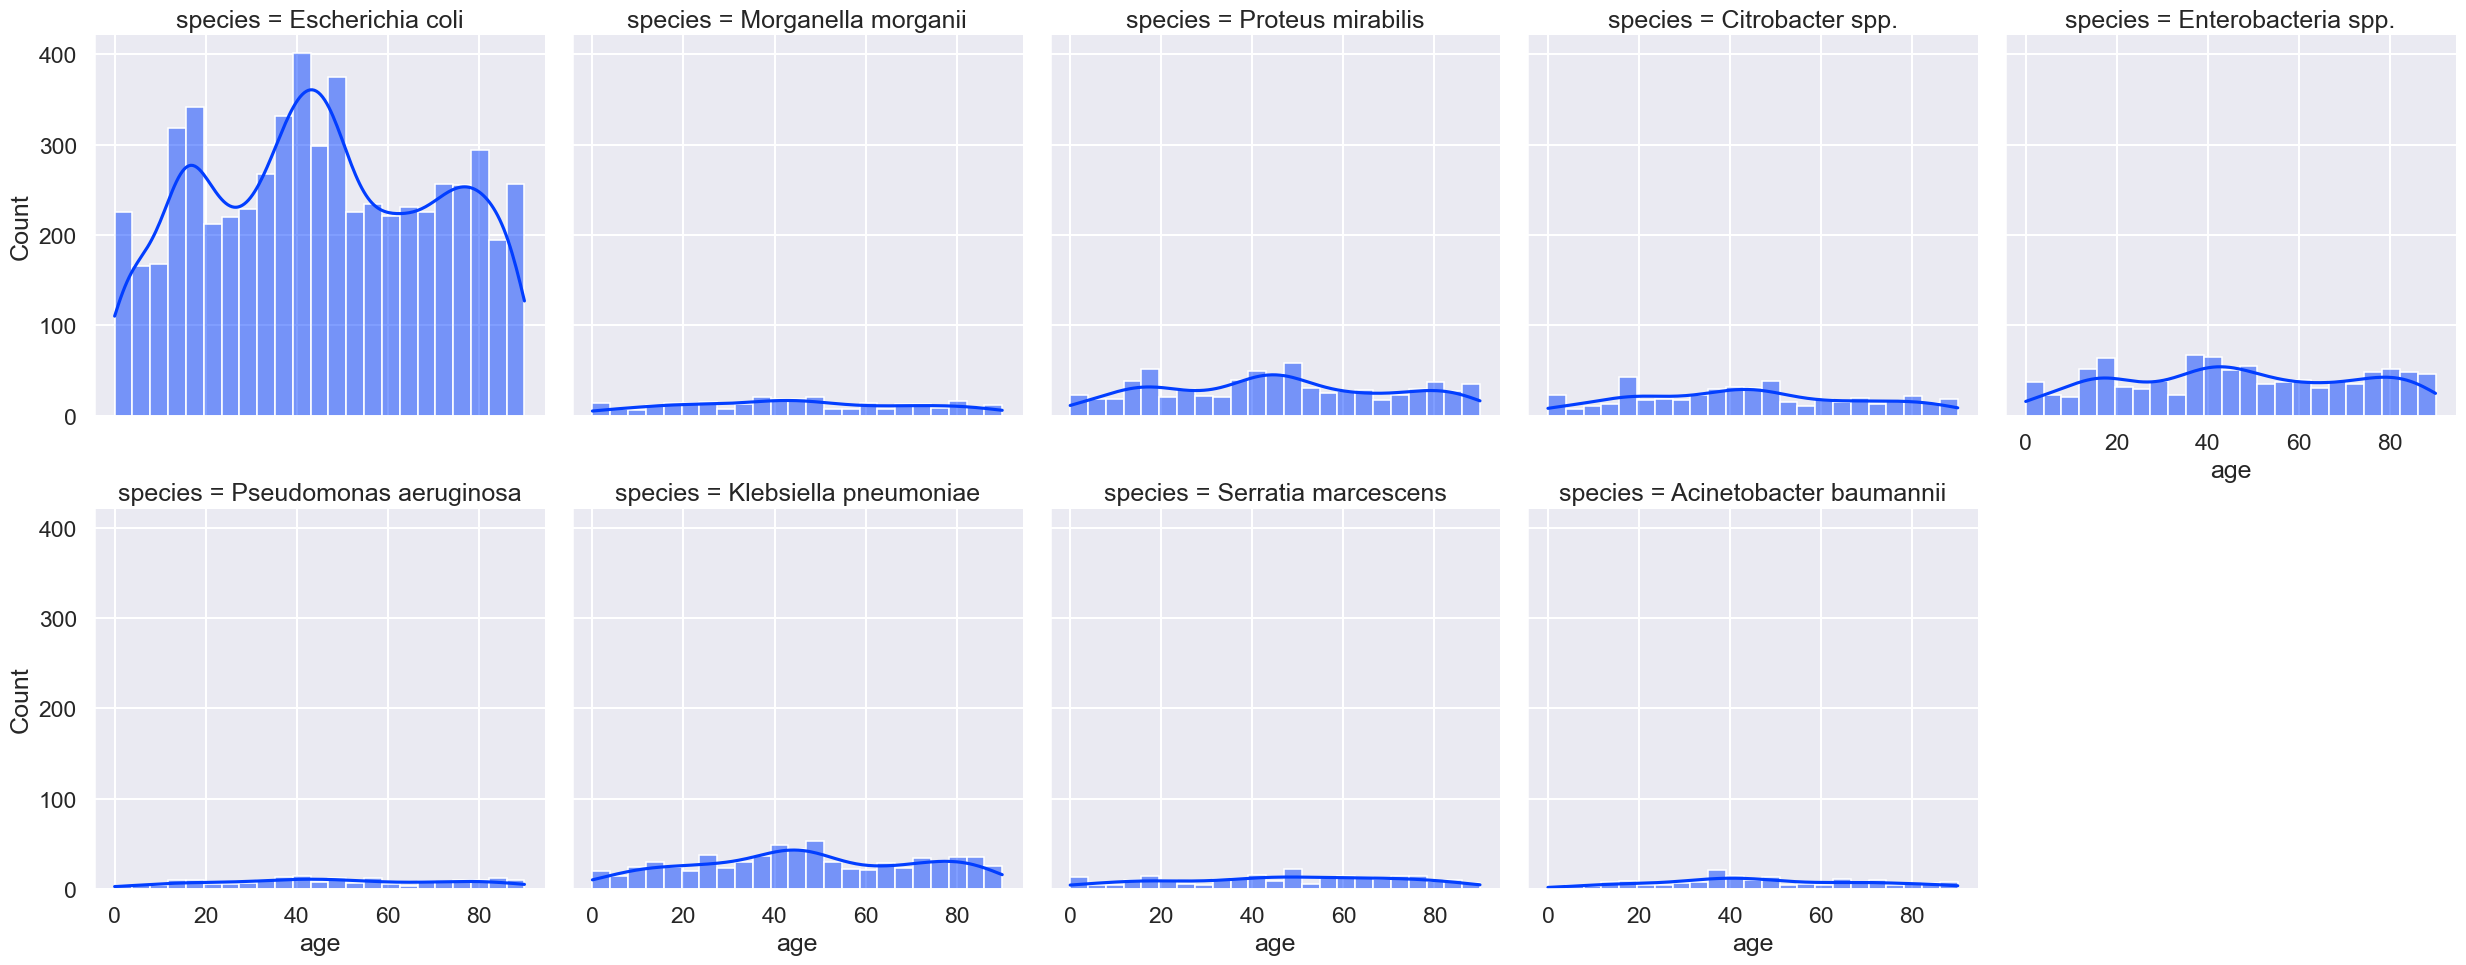

In [36]:
# age and species related
sns.displot(data=df_clean, x='age', col='species', kind='hist', kde=True,col_wrap=5,fill=True,facet_kws={'margin_titles': True})

[Text(10, 0, '177'),
 Text(10, 0, '197'),
 Text(10, 0, '248'),
 Text(10, 0, '292'),
 Text(10, 0, '468'),
 Text(10, 0, '694'),
 Text(10, 0, '719'),
 Text(10, 0, '970'),
 Text(10, 0, '5949')]

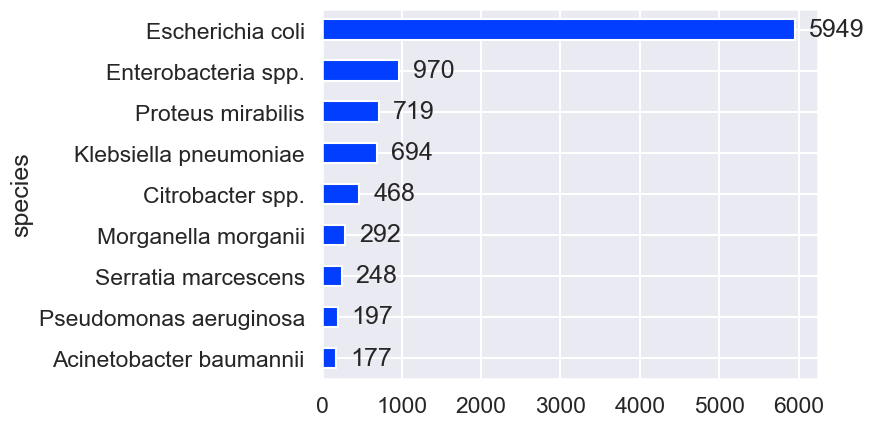

In [37]:
species = df_clean['species'].value_counts().sort_values().plot.barh()
species.bar_label(species.containers[0], padding=10)

Analysis:
1. Many of the people are infected with *Escherichia coli*, especially at the ages of 20s, 40s and 80s, with the 40 year mark showing a significant peak.
2. *Enterobacteria spp*, *Proteus mirabilis* and *Klebsiella penumoniae*,  show significantly low distribution than the *Escherichia coli*, but higher than the other species.
3. All other species show significantly less contributions.

---

## Gender Distributions

Text(0.5, 1.0, 'Count of Males and Females')

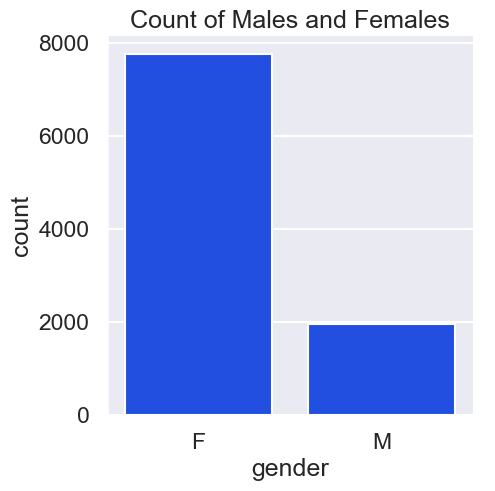

In [38]:
gender = sns.catplot(data=df_clean, x='gender', kind='count')
plt.title('Count of Males and Females')

Most of the data contains data on females

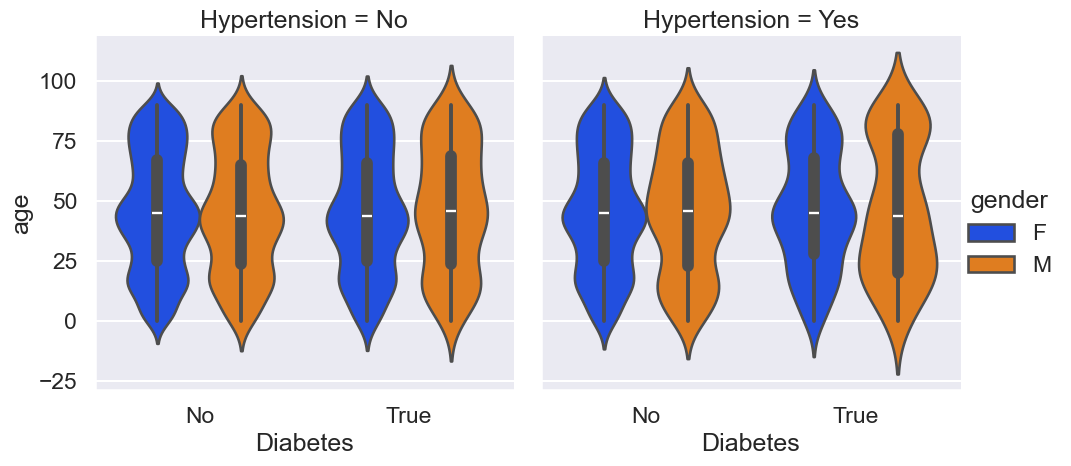

In [39]:
sns.catplot(data=df_clean, x='Diabetes', y='age', hue='gender',col='Hypertension', kind='violin')

There is not much relation between diabetes, hypertension and AMR according to the violin plot

In [40]:
counts_df = df_clean.groupby(['Hypertension', 'Diabetes', 'gender']).size().reset_index(name='Count')
print(counts_df)

  Hypertension Diabetes gender  Count
0           No       No      F   4648
1           No       No      M   1157
2           No     True      F   1191
3           No     True      M    305
4          Yes       No      F   1513
5          Yes       No      M    389
6          Yes     True      F    398
7          Yes     True      M    113


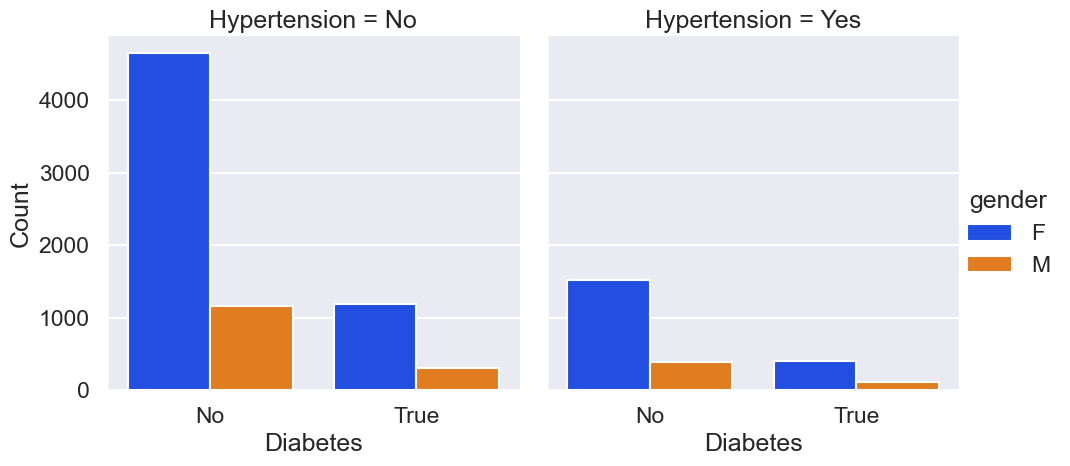

In [41]:
sns.catplot(data=counts_df, x='Diabetes', y='Count', hue='gender',col='Hypertension', kind='bar')

countplot of the violin plot above

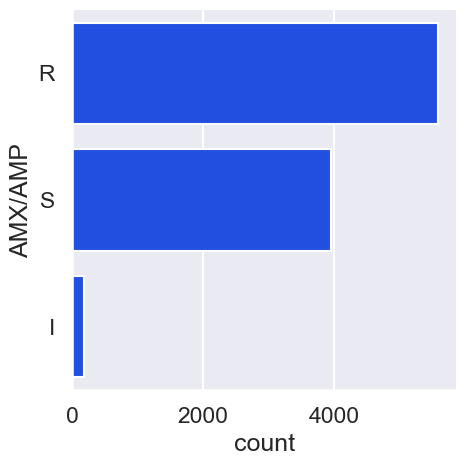

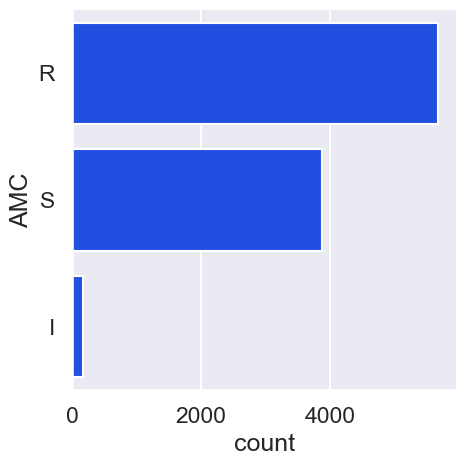

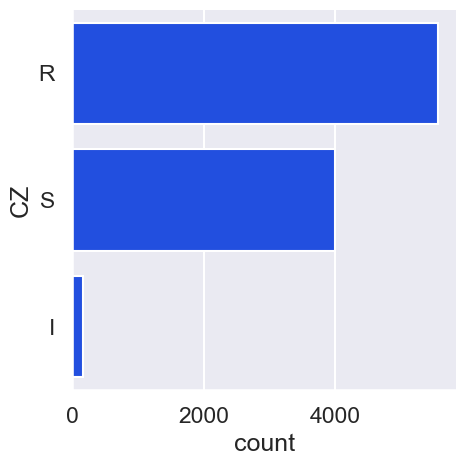

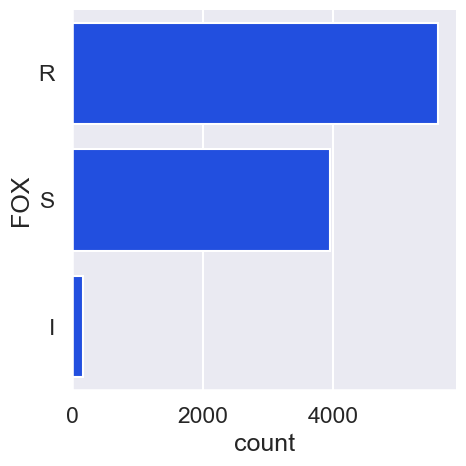

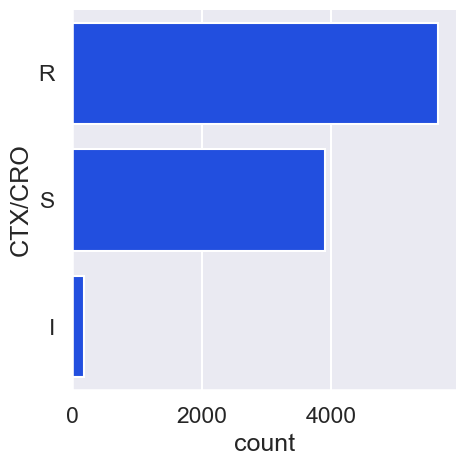

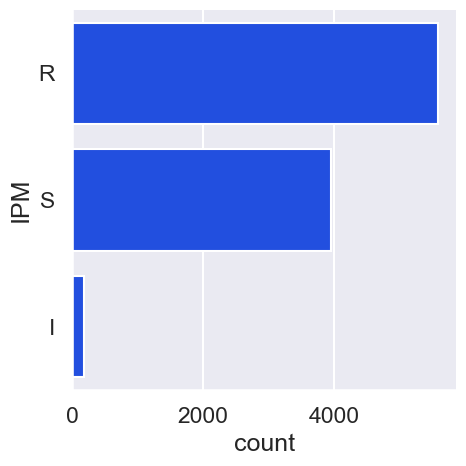

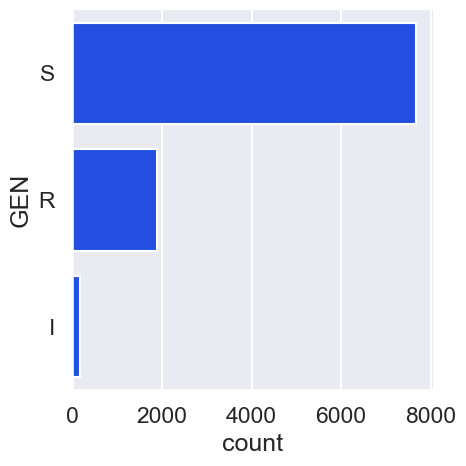

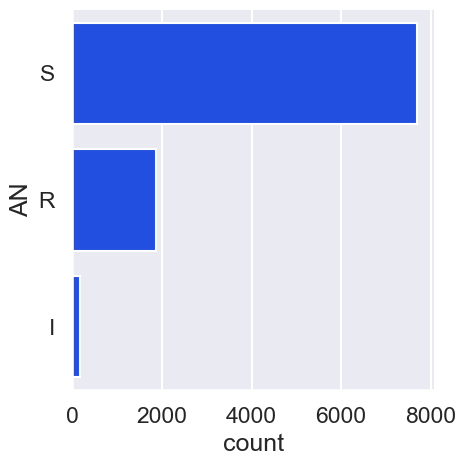

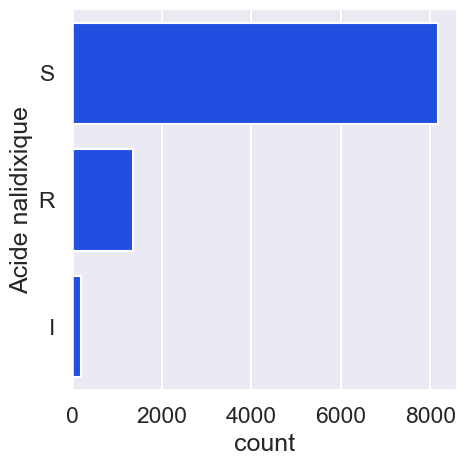

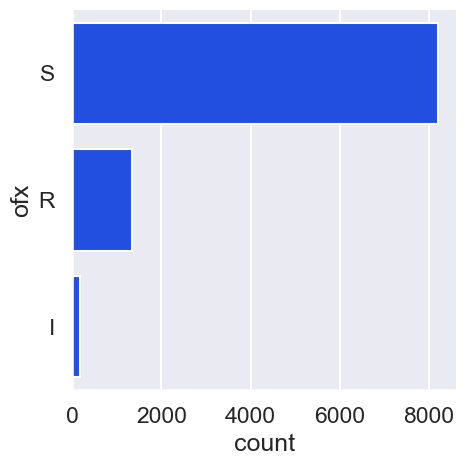

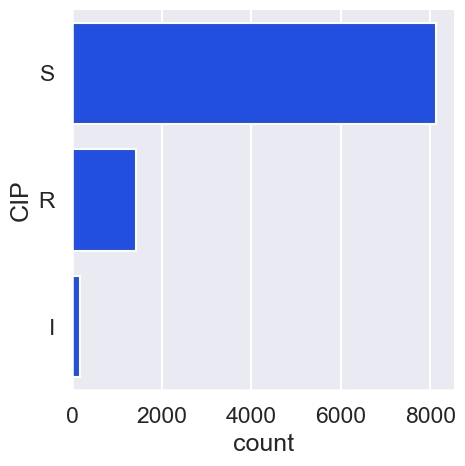

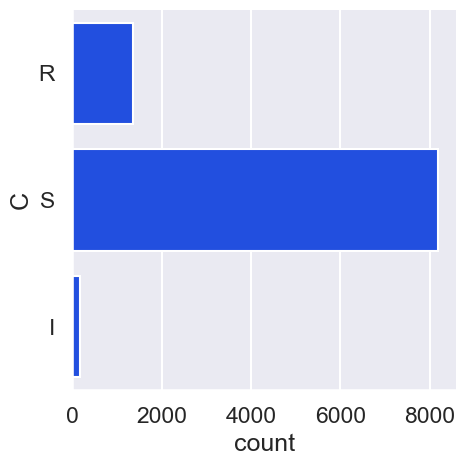

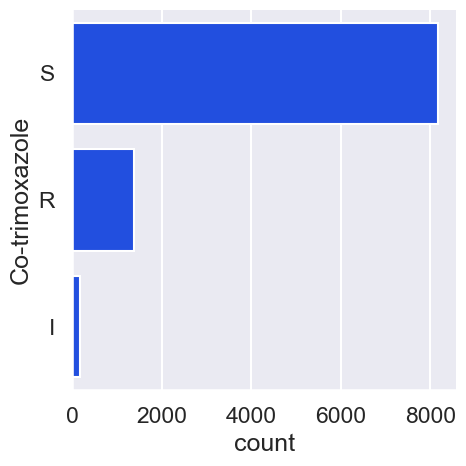

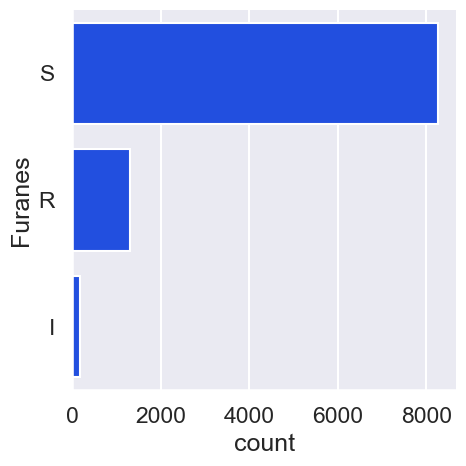

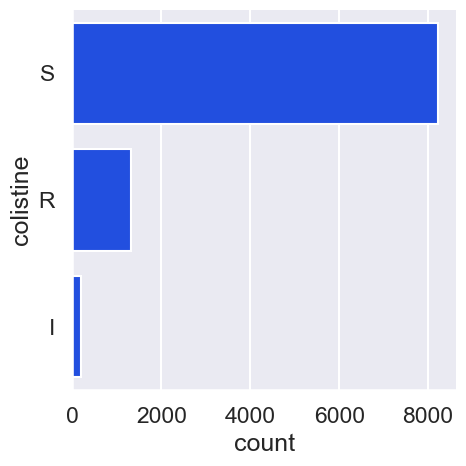

In [52]:
for antibiotics in antibiotic_targetcols:
    sns.catplot(data=df_clean[antibiotics], kind='count')

Most of the resistance is in antibiotics: AMX/AMP, AMC, CZ, FOX, CTX/CRO, IPM.

All of these are Beta-lactam based antibiotics inhibiting cell wall synthesis and majority are resistant to such antibiotics which has become common for beta-lactam based antibiotics.

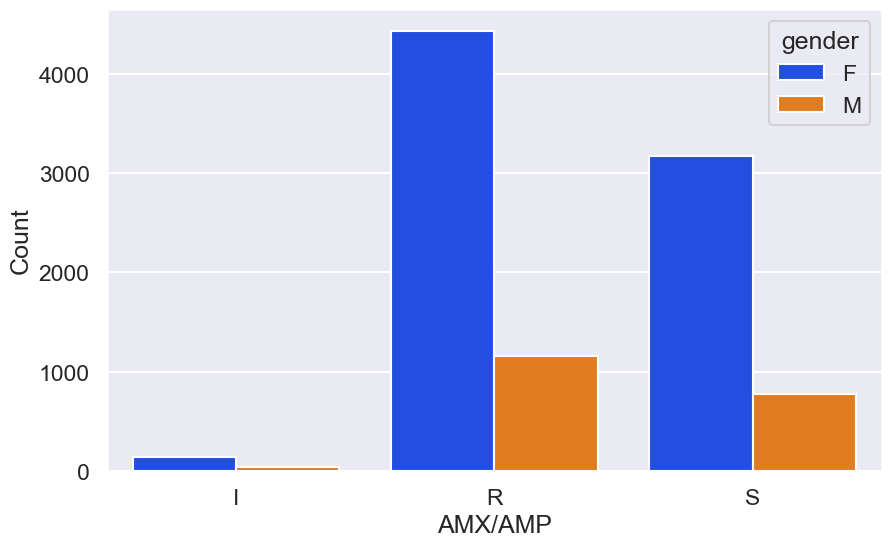

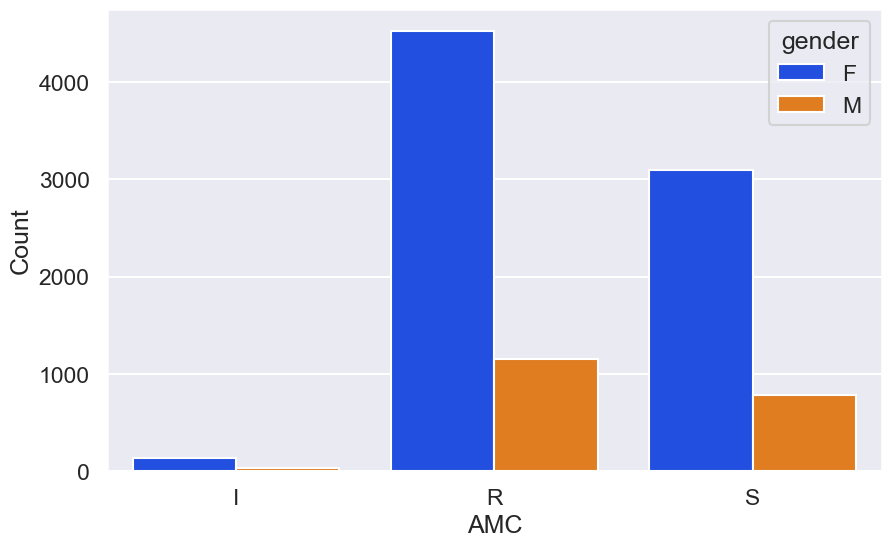

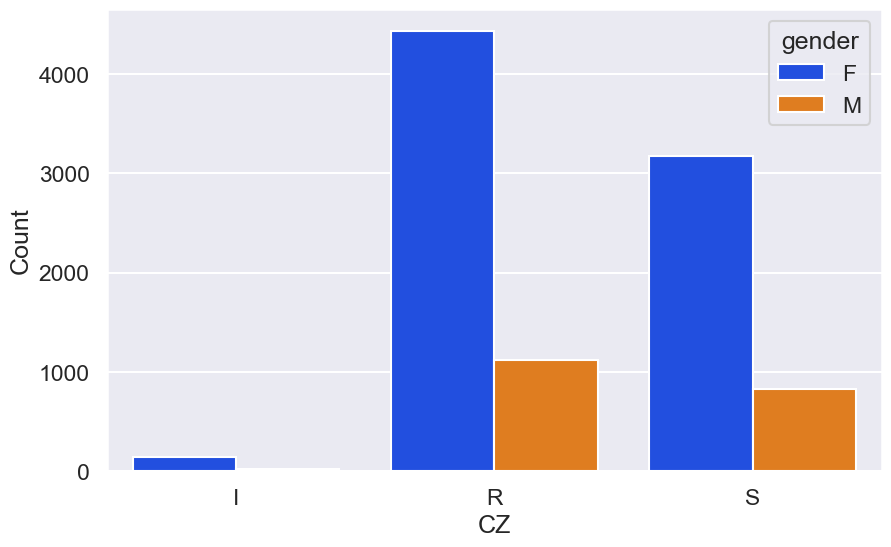

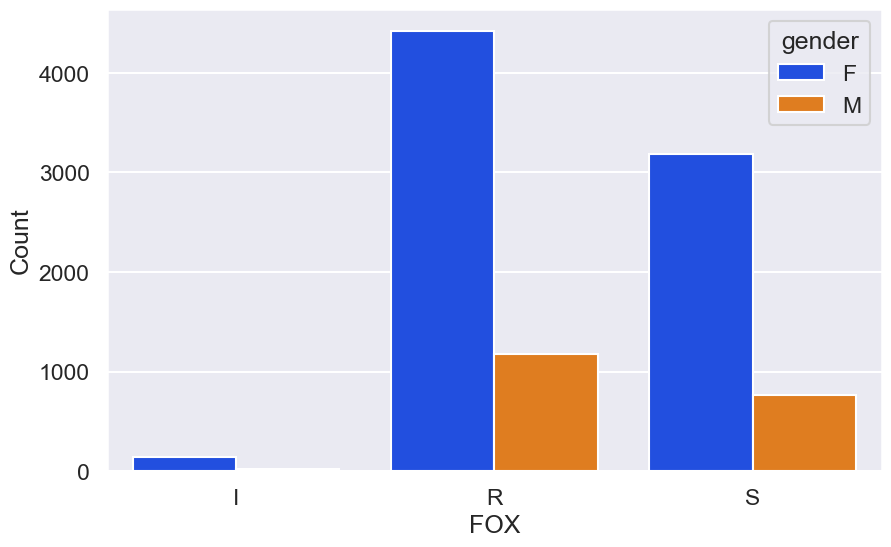

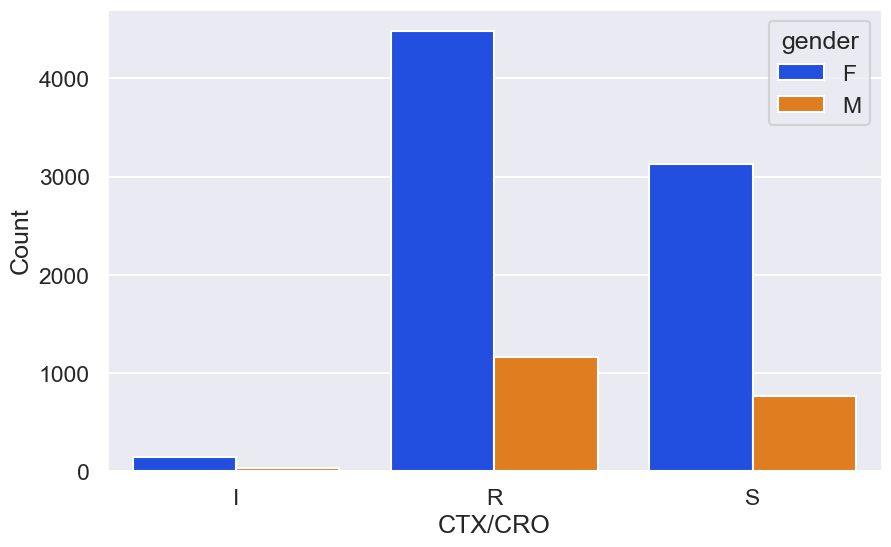

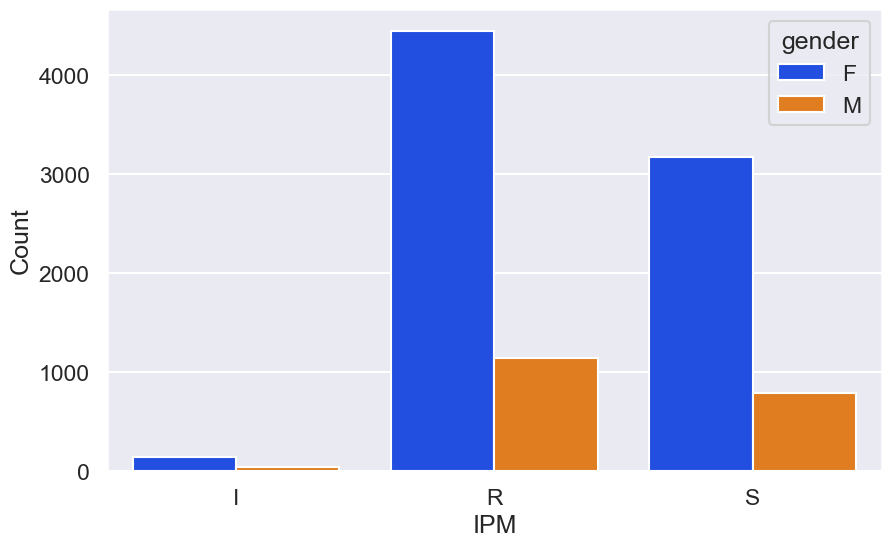

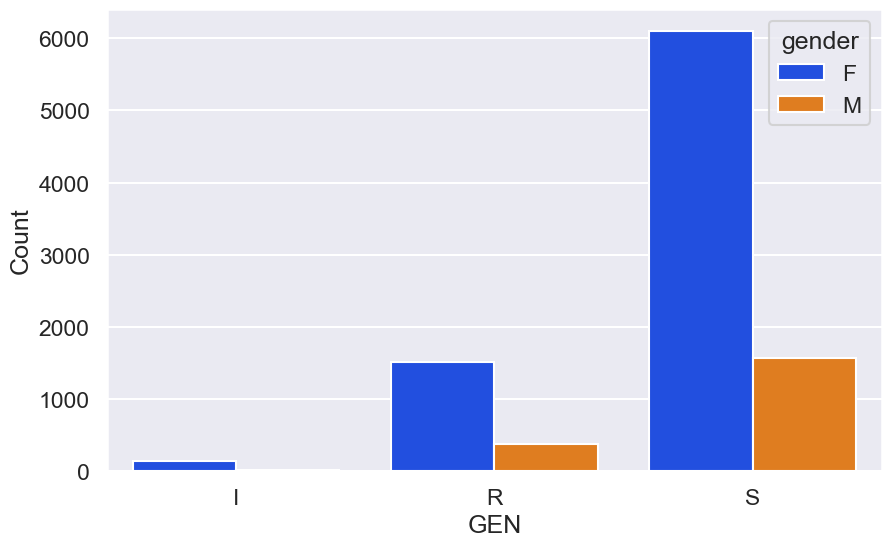

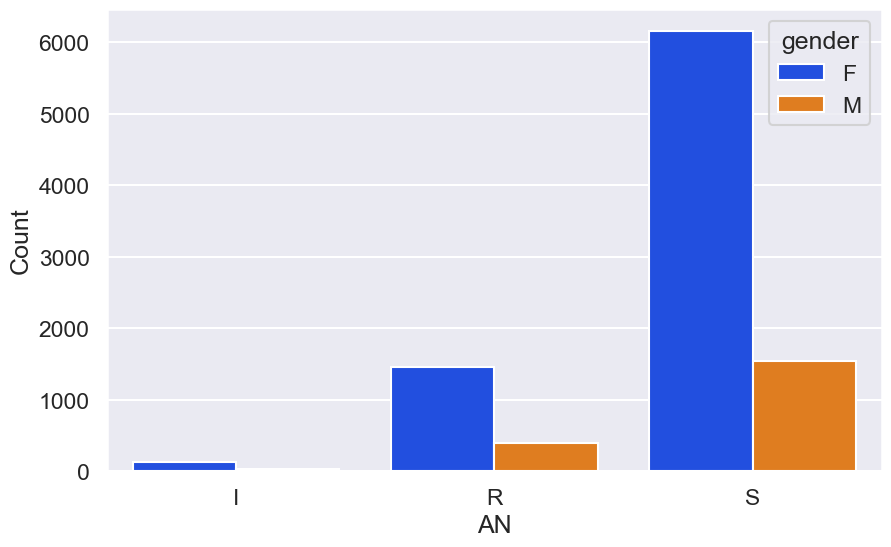

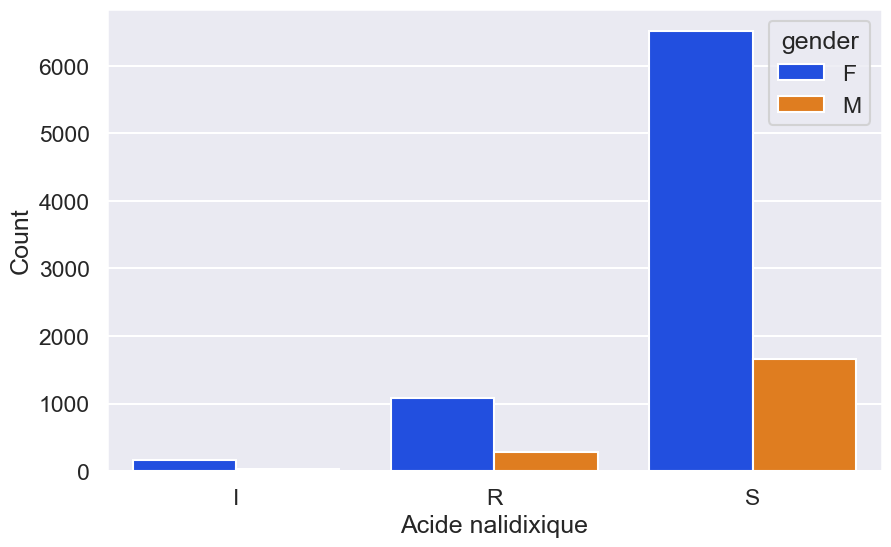

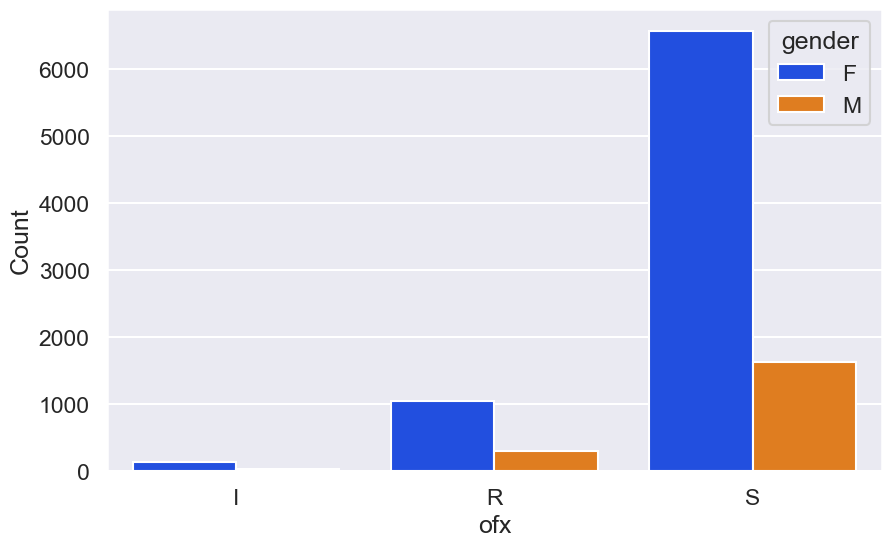

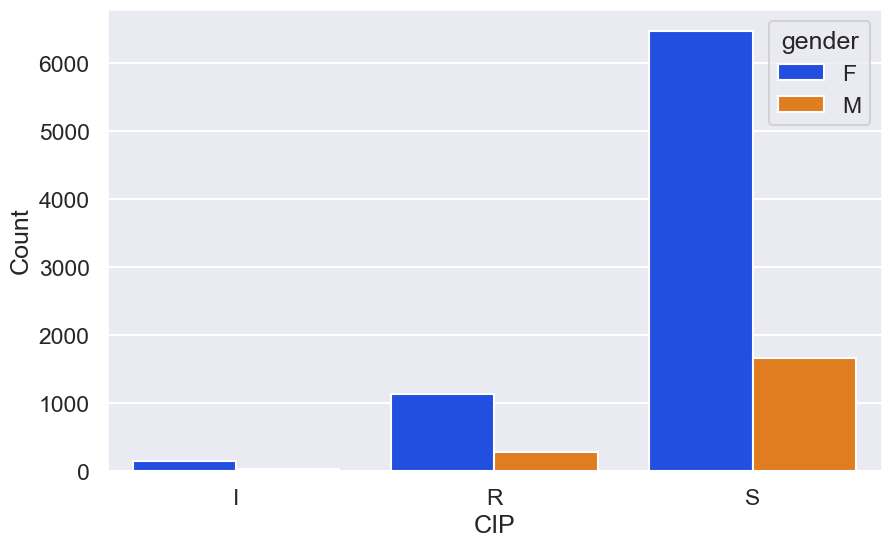

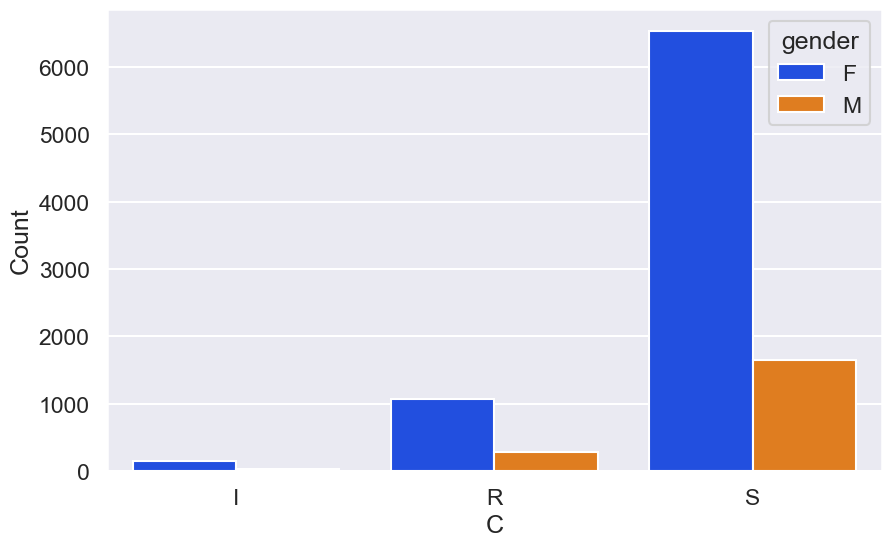

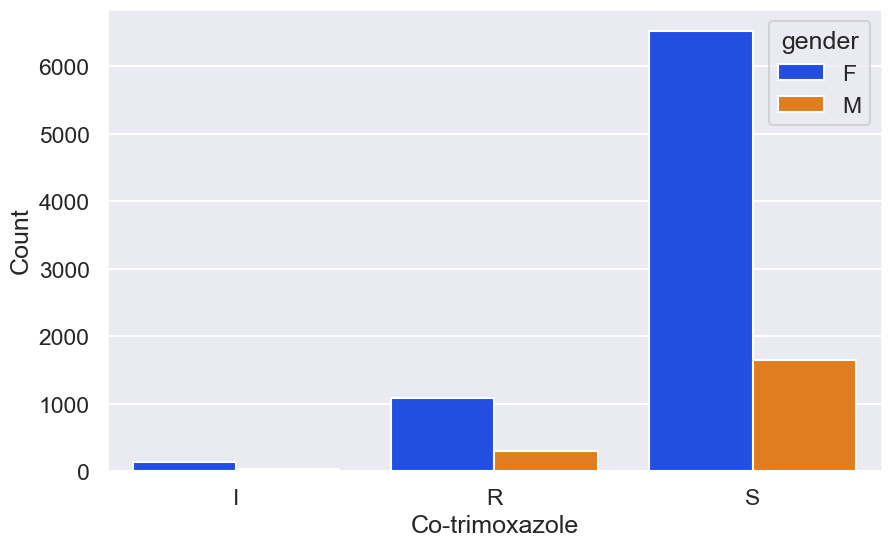

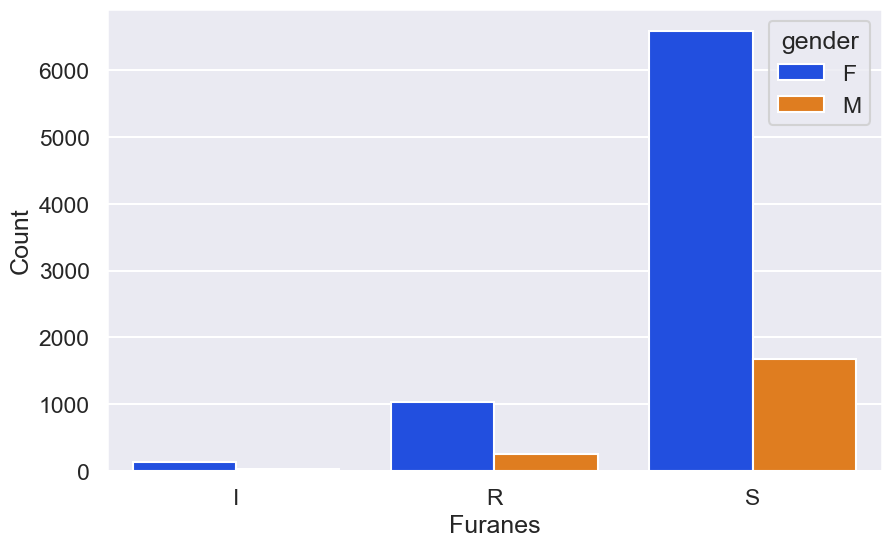

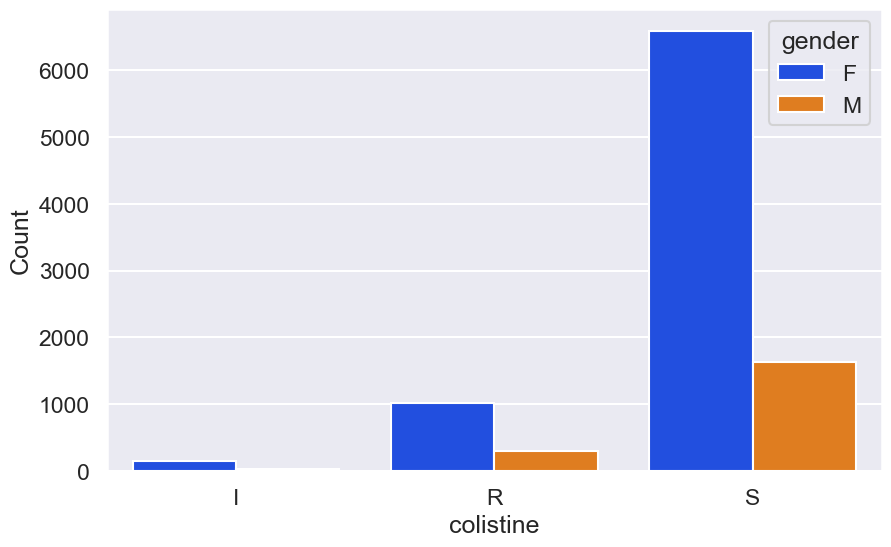

In [56]:
for anti in antibiotic_targetcols:
    counts_data = df_clean.groupby([anti, 'gender']).size().reset_index(name='Count')
    fig, axes = plt.subplots(1,1, figsize=(10,6))
    sns.barplot(data=counts_data, x=anti, y='Count', hue='gender')

In [60]:
df_clean.columns, antibiotic_targetcols

(Index(['Diabetes', 'Hypertension', 'Hospital_before', 'Infection_Freq',
        'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN',
        'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes',
        'colistine', 'species', 'age', 'gender'],
       dtype='object'),
 ['AMX/AMP',
  'AMC',
  'CZ',
  'FOX',
  'CTX/CRO',
  'IPM',
  'GEN',
  'AN',
  'Acide nalidixique',
  'ofx',
  'CIP',
  'C',
  'Co-trimoxazole',
  'Furanes',
  'colistine'])

In [77]:
id_vars = [col for col in df_clean.columns if col not in antibiotic_targetcols]

df_long = pd.melt(
    df_clean,
    id_vars=id_vars,
    value_vars=antibiotic_targetcols,
    var_name='Antibiotic_Type',
    value_name='Status'
)
df_long.head(10)

,Diabetes,Hypertension,Hospital_before,Infection_Freq,species,age,gender,Antibiotic_Type,Status
0,No,No,No,0.0,Escherichia coli,37,F,AMX/AMP,R
1,True,No,No,3.0,Morganella morganii,29,F,AMX/AMP,S
2,True,No,No,3.0,Proteus mirabilis,77,F,AMX/AMP,S
3,No,Yes,No,1.0,Escherichia coli,13,F,AMX/AMP,S
4,True,No,No,3.0,Escherichia coli,57,M,AMX/AMP,R
5,No,No,No,3.0,Escherichia coli,68,F,AMX/AMP,R
6,No,No,No,2.0,Citrobacter spp.,18,F,AMX/AMP,R
7,No,No,No,0.0,Enterobacteria spp.,77,F,AMX/AMP,S
8,No,No,No,3.0,Proteus mirabilis,36,F,AMX/AMP,R
9,True,No,Yes,2.0,Escherichia coli,49,M,AMX/AMP,R


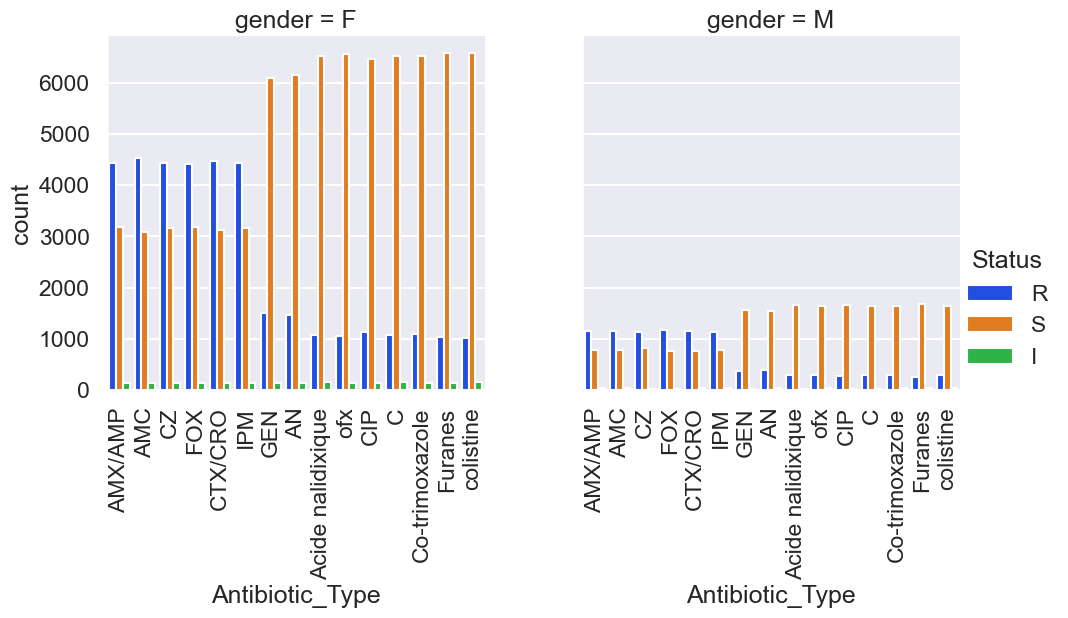

In [76]:
g = sns.catplot(
    data=df_long,
    x='Antibiotic_Type',
    kind='count',
    hue='Status',
    col='gender'
)
g.set_xticklabels(rotation=90)